In [1]:
# Cell 1: Environment Initialization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Configure visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Analysis environment ready.")

Analysis environment ready.


In [2]:
# Cell 2: Data Ingestion and Preprocessing
try:
    # Read the scraped campus nutritional dataset
    df = pd.read_csv('campus_menu_nutrition.csv')
    
    # Coerce calorie data to numeric floats, dropping unparseable string artifacts (e.g., 'N/A')
    df['calories'] = pd.to_numeric(df['calories'], errors='coerce')
    
    # Apply a logical floor to filter out small side items or condiments
    calorie_threshold = 50
    df = df[df['calories'] >= calorie_threshold].copy()
    
    print(f"Successfully loaded {len(df)} menu items.")
    display(df.head())
except FileNotFoundError:
    print("Error: campus_menu_nutrition.csv not found. Run generate_mock_data.py first!")

Successfully loaded 370 menu items.


,date,meal_option,item_name,calories,protein_g,carbs_g,fat_g,saturated_fat_g,sodium_mg,fiber_g,added_sugars_g
0,Tue 08/18 (),Breakfast,Scrambled Eggs,140.0,12.0,0.5,9.0,3.0,320.0,0.0,0.0
1,Tue 08/18 (),Breakfast,Bacon,110.0,7.0,0.5,9.0,3.0,320.0,0.0,0.5
2,Tue 08/18 (),Breakfast,Turkey Sausage Patty,90.0,7.0,0.5,7.0,2.0,280.0,0.0,0.0
3,Tue 08/18 (),Breakfast,Home Fries,140.0,2.0,24.0,4.5,0.5,140.0,2.0,0.0
4,Tue 08/18 (),Breakfast,Bananas Foster French Toast,430.0,9.0,64.0,16.0,9.0,340.0,2.0,30.0


In [3]:
# Cell 3: Acceptable Macronutrient Distribution Ranges (AMDR) Calculations
# Calculate total caloric contribution per macronutrient 
# (Carbohydrates & Protein = 4 kcal/g, Fat = 9 kcal/g)
total_carb_cals = df['carbs_g'].sum() * 4
total_protein_cals = df['protein_g'].sum() * 4
total_fat_cals = df['fat_g'].sum() * 9
total_calculated_cals = total_carb_cals + total_protein_cals + total_fat_cals

# Determine the percentage distribution across the global menu pool
pct_carbs = (total_carb_cals / total_calculated_cals) * 100
pct_protein = (total_protein_cals / total_calculated_cals) * 100
pct_fat = (total_fat_cals / total_calculated_cals) * 100

# Output macro-level compliance report evaluated against federal AMDR bounds
print("--- AMDR MACRONUTRIENT BALANCE REPORT ---")
print(f"Carbohydrates: {pct_carbs:.1f}% (Target: 45-65%) - {'Within AMDR' if 45 <= pct_carbs <= 65 else 'Out of Bounds'}")
print(f"Protein:      {pct_protein:.1f}% (Target: 10-35%) - {'Within AMDR' if 10 <= pct_protein <= 35 else 'Out of Bounds'}")
print(f"Fat:          {pct_fat:.1f}% (Target: 20-35%) - {'Within AMDR' if 20 <= pct_fat <= 35 else 'Out of Bounds'}")

--- AMDR MACRONUTRIENT BALANCE REPORT ---
Carbohydrates: 36.2% (Target: 45-65%) - Out of Bounds
Protein:      17.8% (Target: 10-35%) - Within AMDR
Fat:          46.0% (Target: 20-35%) - Out of Bounds


In [4]:
# Cell 4: Federal Guideline Compliance Evaluation
# Establish aggregate menu averages for detailed micro/macro mapping
menu_averages = {
    "Sodium (mg)": df['sodium_mg'].mean(),
    "Saturated Fat (g)": df['saturated_fat_g'].mean(),
    "Added Sugars (g)": df['added_sugars_g'].mean(),
    "Dietary Fiber (g)": df['fiber_g'].mean(),
    "Protein Mass (g)": df['protein_g'].mean()
}

# Define 1/3 Daily Value (DV) benchmarks to evaluate individual meal viability
meal_benchmarks = {
    "Sodium (mg)": 766.7,       
    "Saturated Fat (g)": 6.6,    
    "Added Sugars (g)": 10.0,    
    "Dietary Fiber (g)": 9.3,    
    "Protein Mass (g)": 16.6     
}

# Categorize metrics by floor (minimum required) or ceiling (maximum allowed) safety thresholds
metric_types = {
    "Sodium (mg)": "Ceiling", "Saturated Fat (g)": "Ceiling", "Added Sugars (g)": "Ceiling",
    "Dietary Fiber (g)": "Floor", "Protein Mass (g)": "Floor"
}

# Calculate absolute count of individual menu items actively breaching federal limits
breach_counts = {
    "Sodium (mg)": (df['sodium_mg'] > 766.7).sum(),
    "Saturated Fat (g)": (df['saturated_fat_g'] > 6.6).sum(),
    "Added Sugars (g)": (df['added_sugars_g'] > 10.0).sum(),
    "Dietary Fiber (g)": (df['fiber_g'] < 9.3).sum(),       
    "Protein Mass (g)": (df['protein_g'] < 16.6).sum()       
}

# Compile status flag evaluation logic into a summary reporting structure
summary_data = []
for metric in menu_averages:
    avg = menu_averages[metric]
    target = meal_benchmarks[metric]
    m_type = metric_types[metric]
    breaches = breach_counts[metric]
    
    # Calculate percentage deviation from the target benchmark
    pct_diff = ((avg - target) / target) * 100
    
    # Assign diagnostic status flags based on metric classification
    if m_type == "Ceiling":
        status = "Exceeds Target" if avg > target else "Safe"
        breach_label = "Items Breaching Ceiling"
    else:
        status = "Meets Target" if avg >= target else "Deficit"
        breach_label = "Items in Deficit"
        
    summary_data.append({
        "Nutrient Metric": metric,
        "Menu Average": round(avg, 1),
        "Meal Benchmark (1/3 DV)": round(target, 1),
        "Pct Deviation": f"{pct_diff:+.1f}%",
        "Aggregate Status": status,
        breach_label: f"{breaches} / {len(df)} items"
    })

# Render standardized compliance summary 
summary_df = pd.DataFrame(summary_data)
print("--- GUIDELINE COMPARISON SUMMARY ---")
display(summary_df)

# Evaluate overarching AMDR compliance boolean state
amdr_pass = (45 <= pct_carbs <= 65) and (10 <= pct_protein <= 35) and (20 <= pct_fat <= 35)
print(f"\nOverall Menu AMDR Alignment Compliant: {amdr_pass}")

--- GUIDELINE COMPARISON SUMMARY ---


,Nutrient Metric,Menu Average,Meal Benchmark (1/3 DV),Pct Deviation,Aggregate Status,Items Breaching Ceiling,Items in Deficit
0,Sodium (mg),256.9,766.7,-66.5%,Safe,10 / 370 items,NaN
1,Saturated Fat (g),2.2,6.6,-66.2%,Safe,13 / 370 items,NaN
2,Added Sugars (g),1.8,10.0,-81.9%,Safe,18 / 370 items,NaN
3,Dietary Fiber (g),0.9,9.3,-90.4%,Deficit,NaN,369 / 370 items
4,Protein Mass (g),6.2,16.6,-62.7%,Deficit,NaN,336 / 370 items



Overall Menu AMDR Alignment Compliant: False


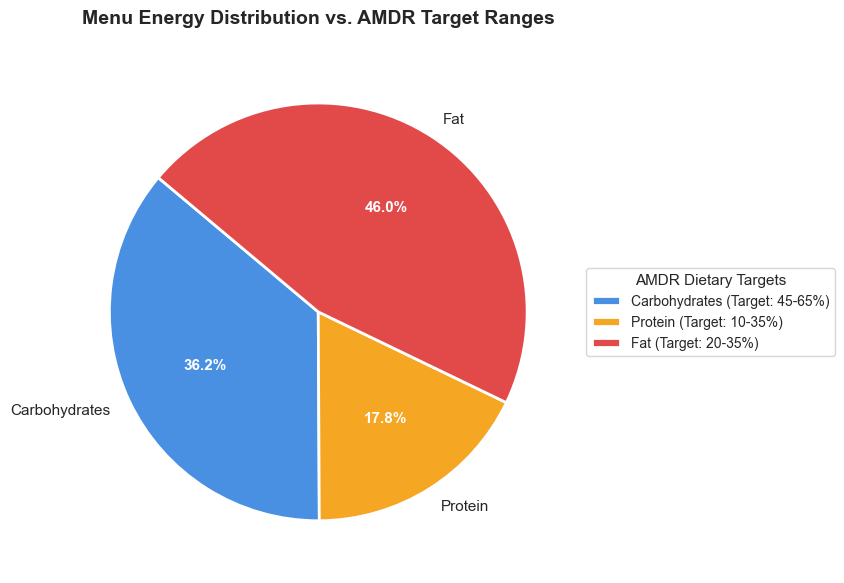

In [5]:
# Cell 5: Visualizations - Menu Energy Distribution
labels = ['Carbohydrates', 'Protein', 'Fat']
sizes = [pct_carbs, pct_protein, pct_fat]
colors = ['#4a90e2', '#f5a623', '#e24a4a']

# Initialize figure architecture
fig, ax = plt.subplots(figsize=(8, 6))

wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 11}
)

# Apply weighting to inner pie percentages
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

# Construct custom legend connecting pie slices to their bounds
legend_labels = [
    "Carbohydrates (Target: 45-65%)",
    "Protein (Target: 10-35%)",
    "Fat (Target: 20-35%)"
]

ax.legend(
    wedges, 
    legend_labels, 
    title="AMDR Dietary Targets", 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1), 
    fontsize=10, 
    title_fontsize=11
)

plt.title('Menu Energy Distribution vs. AMDR Target Ranges', fontsize=14, pad=20, weight='bold')
plt.tight_layout()
plt.show()

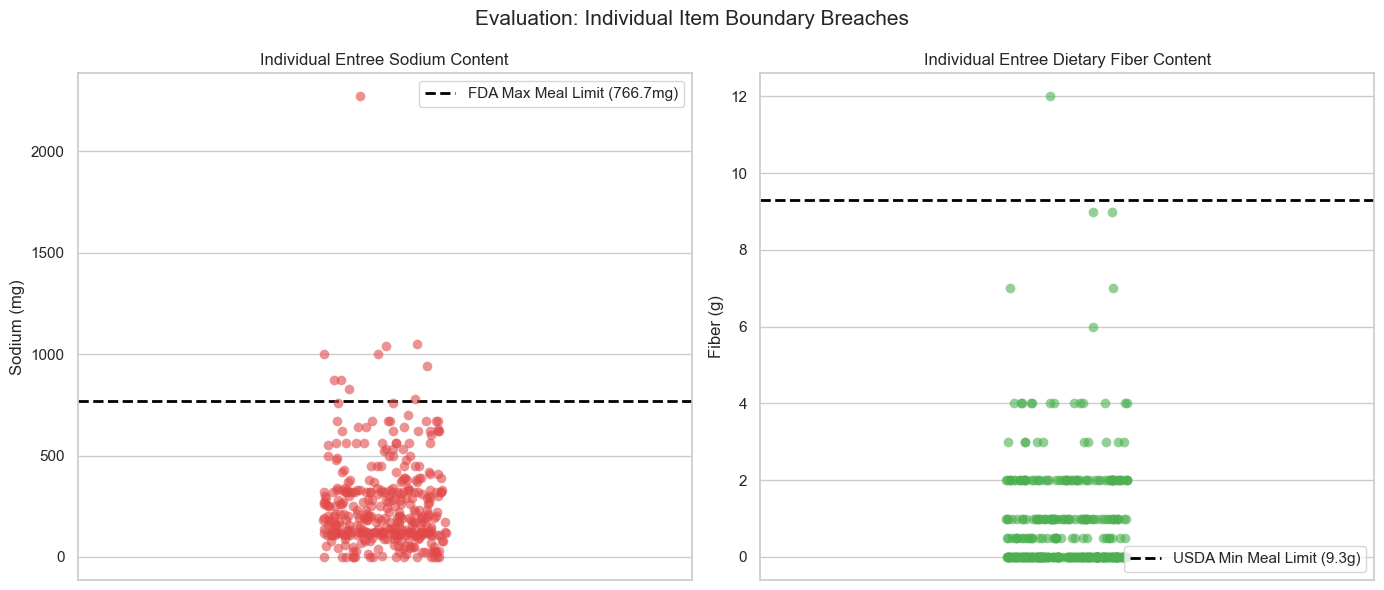

In [6]:
# Cell 6: Visualizations - Threshold Breach Visualizer
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sodium threshold breach evaluation (Ceiling limit mapping)
sns.stripplot(data=df, y='sodium_mg', color='#e24a4a', alpha=0.6, size=7, ax=axes[0])
axes[0].axhline(y=766.7, color='black', linestyle='--', linewidth=2, label='FDA Max Meal Limit (766.7mg)')
axes[0].set_title('Individual Entree Sodium Content', fontsize=12)
axes[0].set_ylabel('Sodium (mg)')
axes[0].legend(loc='upper right')

# Dietary fiber deficit evaluation (Floor limit mapping)
sns.stripplot(data=df, y='fiber_g', color='#4caf50', alpha=0.6, size=7, ax=axes[1])
axes[1].axhline(y=9.3, color='black', linestyle='--', linewidth=2, label='USDA Min Meal Limit (9.3g)')
axes[1].set_title('Individual Entree Dietary Fiber Content', fontsize=12)
axes[1].set_ylabel('Fiber (g)')
axes[1].legend(loc='lower right')

plt.suptitle('Evaluation: Individual Item Boundary Breaches', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

In [7]:
# Cell 7: Nutritional Variance and Predictability Tracking
print("--- NUTRITIONAL VARIANCE ANALYSIS ---")

# Ensure numeric typing across volatility metrics
variance_cols = ['sodium_mg', 'added_sugars_g', 'saturated_fat_g', 'calories']
for col in variance_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Compute descriptive statistics (Standard Deviation) to expose structural menu consistency
variance_summary = df[variance_cols].agg(['mean', 'std', 'min', 'max']).round(1)
display(variance_summary)

--- NUTRITIONAL VARIANCE ANALYSIS ---


,sodium_mg,added_sugars_g,saturated_fat_g,calories
mean,256.9,1.8,2.2,138.9
std,225.8,4.7,2.3,93.3
min,0.0,0.0,0.0,50.0
max,2270.0,41.0,18.0,610.0



--- SCHEDULE PENALTY EVALUATION ---


protein_g       sodium_mg       calories      
                 mean count      mean count     mean count
meal_option                                               
Breakfast         6.5   138     282.7   138    150.7   138
Dinner            7.4   108     269.3   108    149.8   108
Lunch             4.8   124     217.5   124    116.3   124

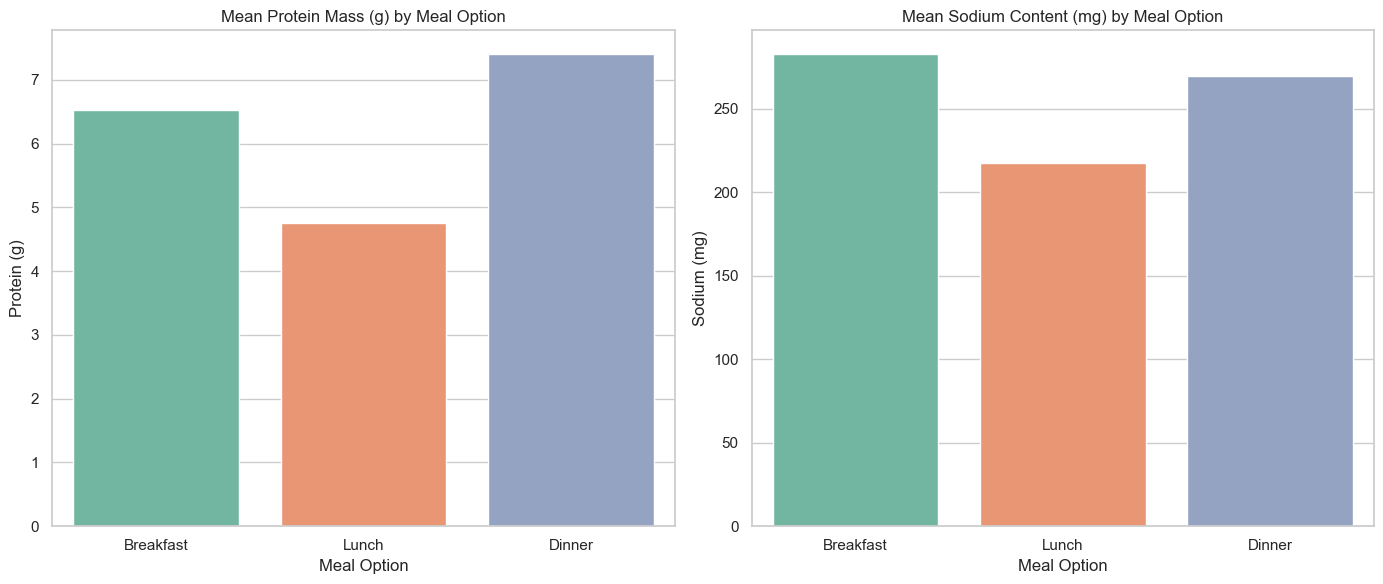

In [8]:
# Cell 8: The "Schedule Penalty" (Temporal Group Comparisons)
print("\n--- SCHEDULE PENALTY EVALUATION ---")

# Aggregate mean nutrient densities grouped by daily meal period
schedule_df = df.groupby('meal_option')[['protein_g', 'sodium_mg', 'calories']].agg(['mean', 'count']).round(1)
display(schedule_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Evaluate Protein Mass Distribution by Meal Option
sns.barplot(
    data=df, 
    x='meal_option', 
    y='protein_g', 
    ax=axes[0], 
    errorbar=None, 
    hue='meal_option', 
    palette='Set2', 
    legend=False
)
axes[0].set_title('Mean Protein Mass (g) by Meal Option')
axes[0].set_ylabel('Protein (g)')
axes[0].set_xlabel('Meal Option')

# Evaluate Sodium Load Risk by Meal Option
sns.barplot(
    data=df, 
    x='meal_option', 
    y='sodium_mg', 
    ax=axes[1], 
    errorbar=None, 
    hue='meal_option', 
    palette='Set2', 
    legend=False
)
axes[1].set_title('Mean Sodium Content (mg) by Meal Option')
axes[1].set_ylabel('Sodium (mg)')
axes[1].set_xlabel('Meal Option')

plt.tight_layout()
plt.show()


--- DENSITY DISTRIBUTIONS ---


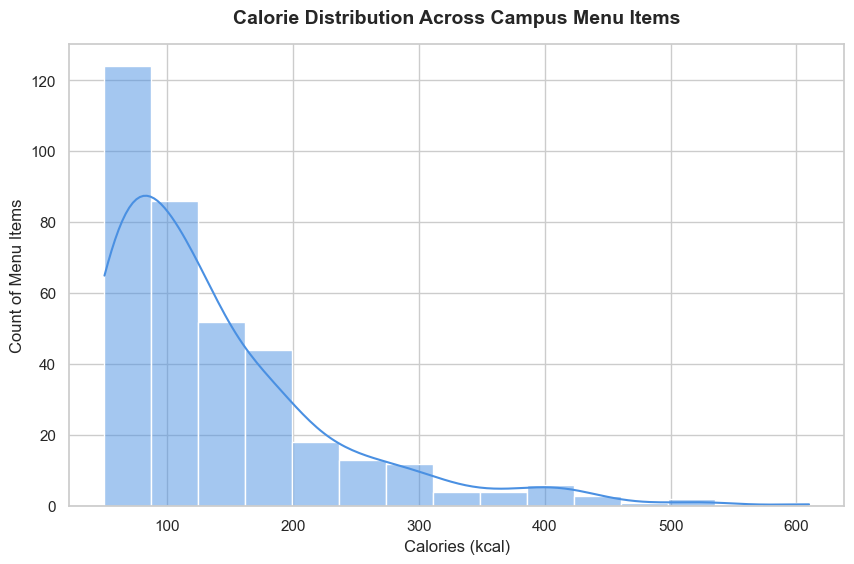

In [9]:
# Cell 9: Calorie Density Distributions
print("\n--- DENSITY DISTRIBUTIONS ---")

plt.figure(figsize=(10, 6))

# Implement Kernel Density Estimate (KDE) interpolation to smooth the 
# distribution curve, assisting in identifying true unimodal vs bimodal structural tendencies
sns.histplot(data=df, x='calories', kde=True, bins=15, color='#4a90e2', edgecolor='white')

plt.title('Calorie Distribution Across Campus Menu Items', fontsize=14, weight='bold', pad=15)
plt.xlabel('Calories (kcal)')
plt.ylabel('Count of Menu Items')
plt.show()

In [10]:
# Cell 10: Two-Sample T-Test (Sodium Gap Analysis)
# Isolate arrays to preform independent significance testing between temporal menu blocks
lunch_sodium = df[df['meal_option'] == 'Lunch']['sodium_mg'].dropna()
dinner_sodium = df[df['meal_option'] == 'Dinner']['sodium_mg'].dropna()

# Execute Welch's T-Test (equal_var=False utilized to assume populations feature unequal variances)
t_stat, p_val_sodium = stats.ttest_ind(lunch_sodium, dinner_sodium, equal_var=False)

print("----TWO-SAMPLE T-TEST (SODIUM GAP ANALYSIS)----")
print(f"Lunch Mean Sodium:   {lunch_sodium.mean():.2f} mg")
print(f"Dinner Mean Sodium:  {dinner_sodium.mean():.2f} mg")
print(f"T-Statistic:         {t_stat:.4f}")
print(f"P-Value:             {p_val_sodium:.4e}")
print("-" * 55)

# Interpret hypothesis outcome against the standard 95% confidence interval 
alpha = 0.05
if p_val_sodium < alpha:
    print(f"CONCLUSION: Reject Null Hypothesis (p < {alpha}).")
    print("The sodium gap between Lunch and Dinner is STATISTICALLY SIGNIFICANT.")
else:
    print(f"CONCLUSION: Fail to Reject Null Hypothesis (p >= {alpha}).")
    print("No statistically significant sodium gap detected between groups.")

----TWO-SAMPLE T-TEST (SODIUM GAP ANALYSIS)----
Lunch Mean Sodium:   217.54 mg
Dinner Mean Sodium:  269.26 mg
T-Statistic:         -1.6526
P-Value:             9.9784e-02
-------------------------------------------------------
CONCLUSION: Fail to Reject Null Hypothesis (p >= 0.05).
No statistically significant sodium gap detected between groups.


In [11]:
# Cell 11: Chi-Square (χ²) Test for Independence
# Evaluate if the likelihood of an item breaching the federal sodium ceiling is dependent on meal period

# Establish binary categorization mapping based on the FDA single-meal maximum threshold
MEAL_SODIUM_BENCHMARK = 766.7
df['sodium_risk'] = np.where(df['sodium_mg'] > MEAL_SODIUM_BENCHMARK, 'High Sodium (>766.7mg)', 'Standard')

# Construct contingency matrix for categorical frequency evaluation
contingency_table = pd.crosstab(df['meal_option'], df['sodium_risk'])
contingency_table = contingency_table.rename_axis(index=None, columns=None)

print("----MEAL OPTION vs. SODIUM RISK----")
display(contingency_table)

# Execute Chi-Square Test to identify statistical dependencies
chi2_stat, p_val_chi2, dof, _ = stats.chi2_contingency(contingency_table)

print("----CHI-SQUARE (χ²) TEST FOR INDEPENDENCE----")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom:   {dof}")
print(f"P-Value:              {p_val_chi2:.4f}")
print("-" * 55)

# Interpret independence results
if p_val_chi2 < alpha:
    print(f"CONCLUSION: Reject Null Hypothesis (p < {alpha}).")
    print("Sodium risk level DEPENDS on the meal option (statistically linked).")
else:
    print(f"CONCLUSION: Fail to Reject Null Hypothesis (p >= {alpha}).")
    print("Sodium risk level and meal option are INDEPENDENT.")

----MEAL OPTION vs. SODIUM RISK----


,High Sodium (>766.7mg),Standard
Breakfast,4,134
Dinner,4,104
Lunch,2,122


----CHI-SQUARE (χ²) TEST FOR INDEPENDENCE----
Chi-Square Statistic: 0.9917
Degrees of Freedom:   2
P-Value:              0.6091
-------------------------------------------------------
CONCLUSION: Fail to Reject Null Hypothesis (p >= 0.05).
Sodium risk level and meal option are INDEPENDENT.
